In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score
from functions import *

# Data Loading

In [2]:
data = pd.read_csv('/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/Omics_integration/results/multiomics_all_samples.csv')

# Set row names
data = data.set_index('Gene.Symbol')

In [3]:
data

,Cn_TCGA-3C-AAAU-01,Cn_TCGA-3C-AALI-01,Cn_TCGA-3C-AALJ-01,Cn_TCGA-3C-AALK-01,Cn_TCGA-4H-AAAK-01,Cn_TCGA-5L-AAT0-01,Cn_TCGA-5L-AAT1-01,Cn_TCGA-5T-A9QA-01,Cn_TCGA-A1-A0SE-01,Cn_TCGA-A1-A0SF-01,...,5'UTR_TCGA-Z7-A8R6-01,Nonsense_Mutation_TCGA-Z7-A8R6-01,Splice_Site_TCGA-Z7-A8R6-01,Splice_Region_TCGA-Z7-A8R6-01,Intron_TCGA-Z7-A8R6-01,3'UTR_TCGA-Z7-A8R6-01,3'Flank_TCGA-Z7-A8R6-01,RNA_TCGA-Z7-A8R6-01,logFC,Chromosome
Gene.Symbol,,,,,,,,,,,,,,,,,,,,,
ACAP3,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
AGRN,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3A,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3B,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3C,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SHANK3,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,-1.73134498491789,chr22
TRABD,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,Non_sign,chr22
TUBGCP6,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,Non_sign,chr22


# Data Wrangling

In [4]:
# Reform the dataset to take the average of cn and me, and the sum of mu types
# Assign the operations 
# extreme_list = ["Cn_", "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']
extreme_list = ["Cn_"]
mean_list = ["Cn", "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf"]
sum_list = ["5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']

# Apply the function for each operation list
agg_sample(data, extreme_list, 'extreme')
agg_sample(data, mean_list, 'mean')
agg_sample(data, sum_list, 'sum')

# Delete data for single samples
data = data[['Cn_', 'Cn', "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf", 
             "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 
             'Intron', "3'UTR", "3'Flank", 'RNA', 'logFC', 'Chromosome']]

# Change column names
data.columns = ['Cn_extreme', 'Cn_mean', "Me_Island", "Me_N_Shore", "Me_S_Shore", "Me_N_Shelf", "Me_S_Shelf", 
             "Mu_5'Flank", "Mu_5'UTR", 'Mu_Nonsense', 'Mu_Splice_Site', 'Mu_Splice_Region', 
             'Mu_Intron', "Mu_3'UTR", "Mu_3'Flank", 'Mu_RNA', 'logFC', 'Chromosome']

In [5]:
# Remove mutation type without mutations
data = data.drop(columns = 'Mu_Splice_Site', axis = 1)
data = data.drop(columns = 'Mu_Splice_Region', axis = 1)
# data = data.drop(columns = 'Me_Island', axis = 1)

In [6]:
# Change mutation columns to binary (if a gene is muated at least in one sample, then we assign 1 to this gene)
data.iloc[:,7:-2] = np.where(data.iloc[:,7:-2] > 0, 1, 0)

In [7]:
# Change target variable
data['gene_type'] = data.apply(conditions, axis=1)

# Add binary target (0: Non-DE genes / 1: DE genes)
data['gene_type'] = np.where(data['gene_type'] == 0, 0, 1)
data = data.drop(columns = ['logFC', 'Chromosome'], axis = 1)

In [8]:
data.gene_type.value_counts()

0    6989
1    1994
Name: gene_type, dtype: int64

In [9]:
data

,Cn_extreme,Cn_mean,Me_Island,Me_N_Shore,Me_S_Shore,Me_N_Shelf,Me_S_Shelf,Mu_5'Flank,Mu_5'UTR,Mu_Nonsense,Mu_Intron,Mu_3'UTR,Mu_3'Flank,Mu_RNA,gene_type
Gene.Symbol,,,,,,,,,,,,,,,
ACAP3,-1.159,-0.144118,0.889598,0.252315,0.876742,0.744749,0.935075,0,0,0,0,0,0,0,0
AGRN,-1.159,-0.144118,0.613730,0.748747,0.805707,0.712530,0.798269,0,0,0,0,0,0,0,0
ATAD3A,-1.159,-0.144118,0.579147,0.747231,0.854824,0.000000,0.000000,0,0,0,0,0,0,0,0
ATAD3B,-1.159,-0.144118,0.375518,0.935386,0.940139,0.650422,0.915811,0,0,0,0,1,0,0,0
ATAD3C,-1.159,-0.144118,0.771164,0.881127,0.667408,0.828967,0.819369,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SHANK3,1.488,-0.166633,0.694185,0.783024,0.692462,0.853706,0.778379,0,0,0,0,0,0,1,1
TRABD,1.488,-0.166633,0.477889,0.898513,0.436017,0.000000,0.000000,0,0,0,0,0,0,0,0
TUBGCP6,1.488,-0.166633,0.477608,0.209530,0.930209,0.000000,0.903407,0,0,0,0,0,0,0,0


# MLP Modeling
### 1) Split data

In [10]:
# Split data
train_val_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['gene_type'])
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['gene_type'])

### 2) Standardization

In [11]:
# Create a MinMaxScaler object to normalize the training data
scaler = MinMaxScaler()

# Fit the scaler to the training data and transform the data
train_scaled = scaler.fit_transform(train_df.iloc[:, 0:-1])

# Transform back to pandas df
train_df.iloc[:, 0:-1] = train_scaled

# Apply scaler to validation and test data
val_scaled = scaler.transform(val_df.iloc[:, 0:-1])
test_scaled = scaler.transform(test_df.iloc[:, 0:-1])

# Transform back to pandas df
val_df.iloc[:, 0:-1] = val_scaled
test_df.iloc[:, 0:-1] = test_scaled

### 3) Assign X and y

In [12]:
# Extract the data and labels from the training and testing sets
train_data, train_labels = train_df.iloc[:, :-1], train_df.iloc[:, -1]
val_data, val_labels = val_df.iloc[:, :-1], val_df.iloc[:, -1]
test_data, test_labels = test_df.iloc[:, :-1], test_df.iloc[:, -1]

### 4) Create custom datasets and data loaders

In [13]:
# Create custom datasets from the training and testing sets
train_dataset = CustomDataset(train_data, train_labels)
val_dataset = CustomDataset(val_data, val_labels)
test_dataset = CustomDataset(test_data, test_labels)

# Set up DataLoaders for the training and testing datasets
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=False)

### 5) Set up MLP model, loss function and optimizer
- **nn.CrossEntropyLoss( )**: Firstly, use softmax to convert raw scores to probabilities; Secondly, compute negative log-likelihood loss.

In [14]:
# Set up the MLP model
model = MLP(input_size=train_data.shape[1],
            hidden_size=32,
            output_size=2,
            l2_reg=0.001)

# Define the class weights as a tensor
DEG_w = np.sum(train_df['gene_type'] == 0)/sum(train_df['gene_type'] == 1)
class_weights = torch.FloatTensor([1.0, DEG_w]) # To make the loss for predicting "1" bigger

# Pass the class weights to the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Set up optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001) # ajust learning rate (lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

# Define device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### 6) Train and evaluate the MLP model on the validation set
- **Average Precision (AP):** A local metric that evaluates the precision at various recall levels.
- **F1 score:** F1 = 2 * (precision * recall) / (precision + recall)

In [15]:
num_epochs = 100
best_val_AUC = float('-inf')
train_losses = []
val_losses = []
train_auc_rocs = []
val_auc_rocs = []
val_APs = []
val_accs = []
val_f1s = []
val_Ts = []
for epoch in range(num_epochs):
    train_loss, train_auc_roc = train(model, train_dataloader, criterion, optimizer, device)
    
    # Append the epoch loss to the lists of training losses
    train_losses.append(train_loss)
    train_auc_rocs.append(train_auc_roc)
    
    # Update the learning rate scheduler
    scheduler.step()
    
    # Print the epoch number and loss
    print('Epoch {}/{}: train loss={:.4f}'.format(epoch+1, num_epochs, train_loss))
    
    # Evaluate the finally updated model from training on the validation set
    val_auc_roc, val_AP, val_accuracy, val_f1, val_T, val_loss = evaluate(model, val_dataloader, criterion, device)
    
    # Append performance metrics of the test set
    val_accs.append(val_accuracy)
    val_auc_rocs.append(val_auc_roc)
    val_APs.append(val_AP)
    val_f1s.append(val_f1)
    val_Ts.append(val_T)
    val_losses.append(val_loss)
    
    print('Epoch {}/{}: AUC-ROC={:.2f}, AP={:.2f}, ACC={:.2f}, F1={:.2f}, Threshold={:.2f}'.format(epoch+1, num_epochs, val_auc_roc, val_AP, val_accuracy, val_f1, val_T))
    

    # Save the latest best model based on AUC-ROC
    if val_auc_roc > best_val_AUC:
        best_val_AUC = val_auc_roc
        torch.save(model.state_dict(), '../models/aggregated_biclass_NonDEG_model.pth')

Epoch 1/100: train loss=0.5459
Epoch 1/100: AUC-ROC=0.64, AP=0.31, ACC=0.57, F1=0.42, Threshold=0.45
Epoch 2/100: train loss=0.5360
Epoch 2/100: AUC-ROC=0.64, AP=0.31, ACC=0.62, F1=0.42, Threshold=0.48
Epoch 3/100: train loss=0.5312
Epoch 3/100: AUC-ROC=0.64, AP=0.32, ACC=0.61, F1=0.42, Threshold=0.45
Epoch 4/100: train loss=0.5297
Epoch 4/100: AUC-ROC=0.65, AP=0.33, ACC=0.62, F1=0.42, Threshold=0.47
Epoch 5/100: train loss=0.5270
Epoch 5/100: AUC-ROC=0.65, AP=0.34, ACC=0.62, F1=0.42, Threshold=0.46
Epoch 6/100: train loss=0.5255
Epoch 6/100: AUC-ROC=0.66, AP=0.34, ACC=0.64, F1=0.43, Threshold=0.49
Epoch 7/100: train loss=0.5229
Epoch 7/100: AUC-ROC=0.64, AP=0.34, ACC=0.55, F1=0.40, Threshold=0.45
Epoch 8/100: train loss=0.5220
Epoch 8/100: AUC-ROC=0.66, AP=0.36, ACC=0.66, F1=0.43, Threshold=0.51
Epoch 9/100: train loss=0.5209
Epoch 9/100: AUC-ROC=0.65, AP=0.36, ACC=0.62, F1=0.43, Threshold=0.48
Epoch 10/100: train loss=0.5190
Epoch 10/100: AUC-ROC=0.66, AP=0.36, ACC=0.67, F1=0.43, Thr

Epoch 81/100: train loss=0.5044
Epoch 81/100: AUC-ROC=0.67, AP=0.37, ACC=0.69, F1=0.44, Threshold=0.51
Epoch 82/100: train loss=0.5054
Epoch 82/100: AUC-ROC=0.67, AP=0.37, ACC=0.65, F1=0.44, Threshold=0.44
Epoch 83/100: train loss=0.5029
Epoch 83/100: AUC-ROC=0.67, AP=0.37, ACC=0.65, F1=0.44, Threshold=0.43
Epoch 84/100: train loss=0.5048
Epoch 84/100: AUC-ROC=0.67, AP=0.37, ACC=0.66, F1=0.43, Threshold=0.47
Epoch 85/100: train loss=0.5049
Epoch 85/100: AUC-ROC=0.67, AP=0.37, ACC=0.67, F1=0.44, Threshold=0.48
Epoch 86/100: train loss=0.5045
Epoch 86/100: AUC-ROC=0.67, AP=0.37, ACC=0.68, F1=0.44, Threshold=0.48
Epoch 87/100: train loss=0.5050
Epoch 87/100: AUC-ROC=0.67, AP=0.37, ACC=0.66, F1=0.43, Threshold=0.47
Epoch 88/100: train loss=0.5037
Epoch 88/100: AUC-ROC=0.67, AP=0.37, ACC=0.65, F1=0.43, Threshold=0.46
Epoch 89/100: train loss=0.5049
Epoch 89/100: AUC-ROC=0.67, AP=0.37, ACC=0.64, F1=0.44, Threshold=0.45
Epoch 90/100: train loss=0.5038
Epoch 90/100: AUC-ROC=0.67, AP=0.37, ACC=

In [16]:
print('Best Val AUC-ROC: {:.2f}'.format(max(val_auc_rocs)))
print('Best Val AP: {:.2f}'.format(max(val_APs)))
print('Best Val ACC: {:.2f}'.format(max(val_accs)))
print('Best Val F1: {:.2f}'.format(max(val_f1s)))

Best Val AUC-ROC: 0.67
Best Val AP: 0.39
Best Val ACC: 0.70
Best Val F1: 0.44


# Model Evaluation on Test Set

In [17]:
# Load the saved model
saved_model_filename = '../models/aggregated_biclass_NonDEG_model.pth'
model.load_state_dict(torch.load(saved_model_filename))

<All keys matched successfully>

In [18]:
# Evaluate the model on the validation data
val_auc_roc, val_AP, val_accuracy, val_f1, val_T, val_loss = evaluate(model, val_dataloader, criterion, device)
print('Validation set: AUC-ROC={:.2f}, AP={:.2f}, ACC={:.2f}, F1={:.2f}, Threshold={:.2f}, Loss={:.2f}'.format(val_auc_roc, val_AP, val_accuracy, val_f1, val_T, val_loss))

# Evaluate the model on the test data
test_auc_roc, test_AP, test_accuracy, test_f1, test_T, test_loss = evaluate(model, test_dataloader, criterion, device)
print('Test set: AUC-ROC={:.2f}, AP={:.2f}, ACC={:.2f}, F1={:.2f}, Threshold={:.2f}, Loss={:.2f}'.format(test_auc_roc, test_AP, test_accuracy, test_f1, test_T, test_loss))

Validation set: AUC-ROC=0.67, AP=0.38, ACC=0.62, F1=0.44, Threshold=0.45, Loss=0.52
Test set: AUC-ROC=0.67, AP=0.36, ACC=0.66, F1=0.44, Threshold=0.49, Loss=0.45


# Visualization

### 1) Training loss vs. Validation loss

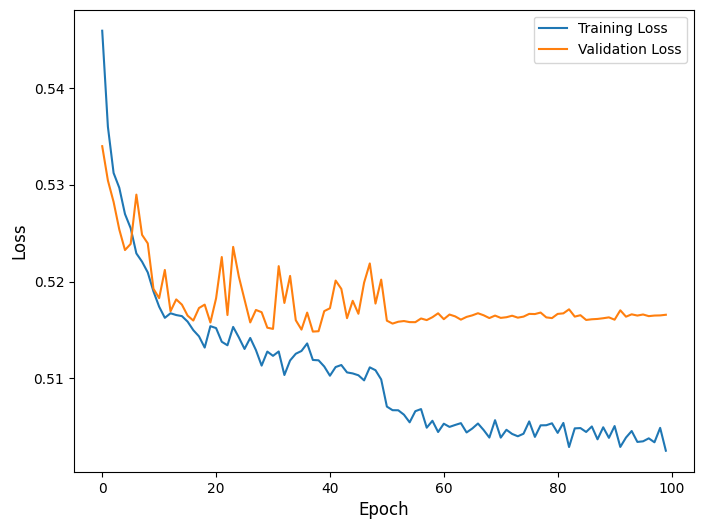

In [19]:
plt.rcParams["figure.figsize"] = (8,6)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.savefig('../figures/agg_biclass_NonDEG_loss.png', dpi=300, bbox_inches="tight")

### 2) Train AUC-ROC vs. Validation AUC-ROC

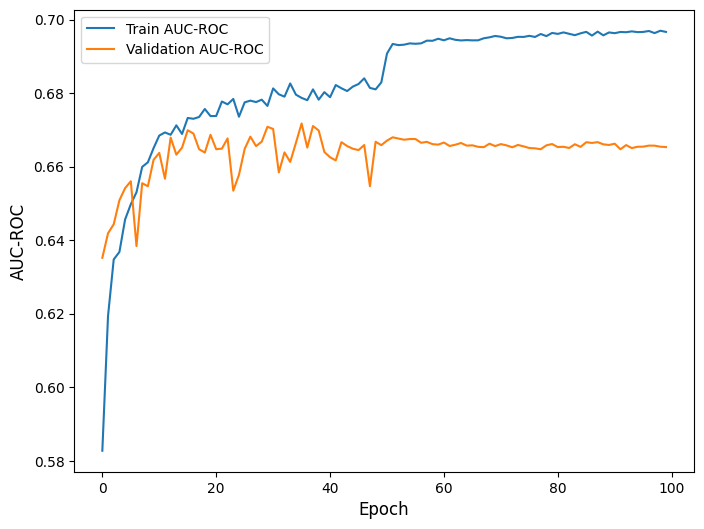

In [20]:
# Plot the ACC and AUC values of training and test set over time
plt.rcParams["figure.figsize"] = (8,6)
plt.plot(train_auc_rocs, label='Train AUC-ROC')
plt.plot(val_auc_rocs, label='Validation AUC-ROC')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.legend()
plt.savefig('../figures/agg_biclass_NonDEG_AUC.png', dpi=300, bbox_inches="tight")

### 3) Saliency Map

In [21]:
# Merge data
standardized_data = pd.concat([train_df, val_df, test_df], axis=0)

#### 3.1) For true DEGs

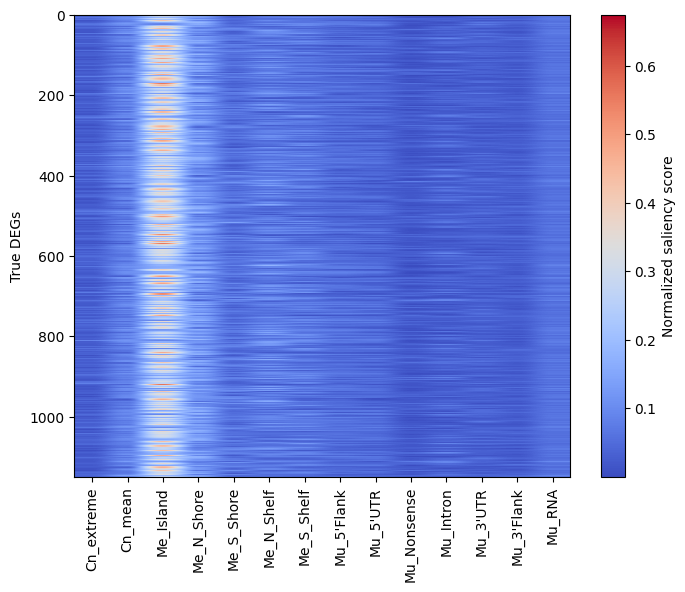

In [22]:
# Saliency heatmap
TP_scores, TP_genes = saliency_heatmap(model=model,
                                       data=standardized_data,
                                       class_index=1,
                                       bi_class=True,
                                       onlyDEG=False)

In [23]:
# Number of TP_genes
len(TP_genes)

1150

In [24]:
# Save the truly-predicted DEGs
trueDEGs_df = standardized_data.loc[TP_genes]
trueDEGs_df.to_csv('../results/biclass_trueDEGs_data.csv')

In [25]:
# Find the feature with the maximal score for each gene
max_index = np.argmax(TP_scores, axis=1)
picked_index = np.where(max_index >= 7)[0].tolist()
picked_genes = [TP_genes[i] for i in picked_index]
print("Truly-predicted DEGs mostly affected by mutation:", picked_genes)

Truly-predicted DEGs mostly affected by mutation: ['ALX4', 'KLF2']


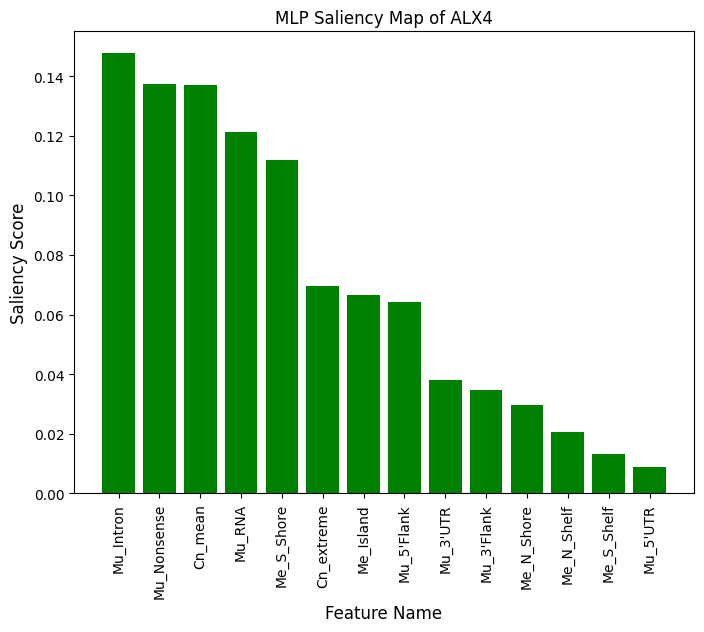

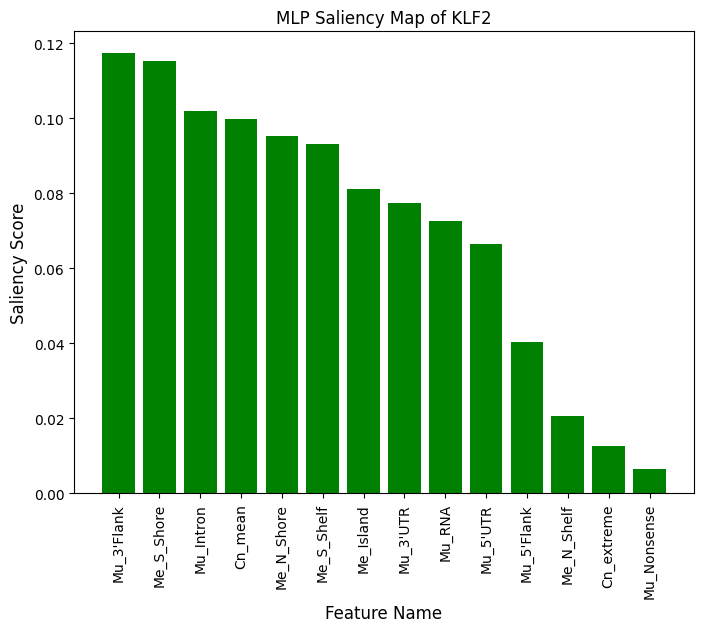

In [26]:
# Check saliency barplot for the picked genes above
for gene in picked_genes:
    gene_score = TP_scores[TP_genes.index(gene)]
    visualize_saliency(saliency=gene_score,
                       feature_names=standardized_data.columns[:-1],
                       gene_name=gene,
                       data=standardized_data)

#### 3.2) For true NonDEGs

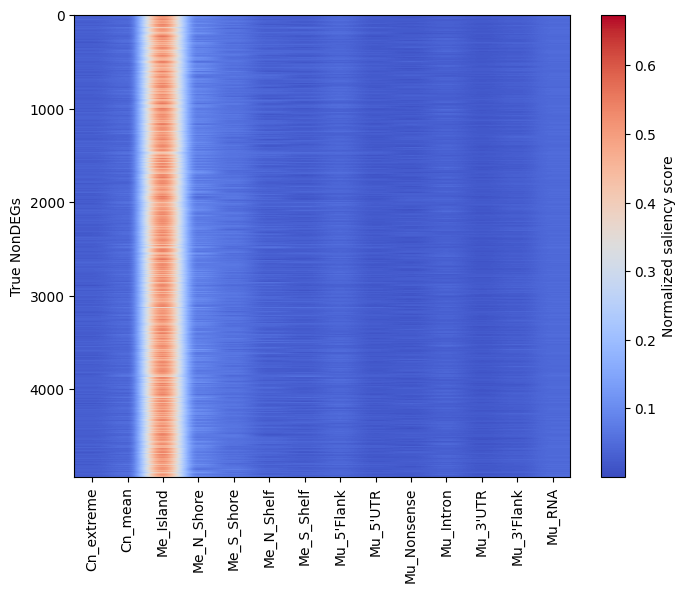

In [27]:
# Saliency heatmap
TN_scores, TN_genes = saliency_heatmap(model=model,
                                       data=standardized_data,
                                       class_index=0,
                                       bi_class=True,
                                       onlyDEG=False)

In [28]:
# Number of TN_genes
len(TN_genes)

4936

In [29]:
# Save the truly-predicted NonDEGs
trueNonDEGs_df = standardized_data.loc[TN_genes]
trueNonDEGs_df.to_csv('../results/biclass_trueNonDEGs_data.csv')

In [30]:
# Find the feature with the maximal score for each gene
max_index = np.argmax(TN_scores, axis=1)
picked_index = np.where(max_index >= 7)[0].tolist()
picked_genes = [TN_genes[i] for i in picked_index]
print("Truly-predicted NonDEGs mostly affected by mutation:", picked_genes)

Truly-predicted NonDEGs mostly affected by mutation: []
